# `center_momentum` × 배치 크기 — center 노이즈를 실제로 재보기

카드 주장: **center는 배치 통계의 EMA이므로 배치가 아주 작으면 center가 노이즈에 흔들리고,
그 결과 centering의 붕괴 방지력이 떨어진다.**

네 가지를 실증한다.

- (a) 정상상태 center 표준편차가 이론식 $\sigma\sqrt{\dfrac{1-m}{(1+m)B}}$ 와 맞는가
- (b) $m$을 올려 노이즈를 줄이면 **추적이 느려진다** (노이즈 ↔ 지연 트레이드오프)
- (c) $\tau_t=0.04$가 center 노이즈를 **25배 증폭**해서 확률 공간에 꽂는다
- (d) 토이 학습에서 centering의 유효 배치 $B_{\text{eff}}$만 줄여 실제로 붕괴가 나는지

In [1]:
import math
import os
import copy

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import plotly.graph_objects as go
from plotly.subplots import make_subplots


def _show(fig):
    try:
        from IPython import get_ipython
        if get_ipython() is not None:
            fig.show()
    except ImportError:
        pass


try:
    HERE = os.path.dirname(os.path.abspath(__file__))
except NameError:
    HERE = os.getcwd()

# dataviz 레퍼런스 팔레트 (light surface)
SURFACE, INK, INK2, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#e6e5e1"
# m은 크기(magnitude)라서 순서형 단일 색상(파랑) 램프를 쓴다
SEQ = ["#86b6ef", "#5598e7", "#2a78d6", "#256abf", "#184f95", "#0d366b"]
CAT = ["#2a78d6", "#eb6834", "#1baf7a"]          # 범주형 슬롯 1~3

np.random.seed(0)
torch.manual_seed(0)
print("numpy", np.__version__, "| torch", torch.__version__)

numpy 1.26.4 | torch 2.4.0+cu121


## (a) 정상상태 분산 공식 유도와 검증

1. 배치 평균 $\bar z_t=\frac1B\sum_j z_j$ 의 분산은 $\sigma^2/B$.
2. `update_center`의 EMA $c_t=m\,c_{t-1}+(1-m)\bar z_t$ 를 펼치면
   $c_t=(1-m)\sum_{k\ge0}m^k\,\bar z_{t-k}$.
3. $\bar z$ 들이 독립이므로
   $\operatorname{Var}(c)=(1-m)^2\!\sum_k m^{2k}\cdot\frac{\sigma^2}{B}
    =\frac{(1-m)^2}{1-m^2}\cdot\frac{\sigma^2}{B}
    =\frac{1-m}{1+m}\cdot\frac{\sigma^2}{B}$.

$$\operatorname{std}(c)=\sigma\sqrt{\frac{1-m}{(1+m)B}},\qquad
  B_{\text{eff}}=B\cdot\frac{1+m}{1-m}$$

아래는 실제로 $\mathcal N(0,\sigma^2)$ 에서 크기 $B$ 배치를 뽑아 EMA를 돌리고 시간평균 표준편차를 잰다.

In [2]:
def theory_std(B, m, sigma=1.0):
    return sigma * math.sqrt((1.0 - m) / ((1.0 + m) * B))


def simulate_center_std(B, m, sigma=1.0, seed=0, max_draws=4e7):
    tau_ema = 1.0 / max(1e-9, 1.0 - m)
    steps = int(np.clip(400.0 * tau_ema, 20000, 400000))
    if steps * B > max_draws:
        steps = max(20000, int(max_draws // B))
    burn = min(steps // 2, int(20 * tau_ema) + 200)
    rng = np.random.default_rng(seed)
    c, acc = 0.0, []
    for t in range(steps):
        bm = rng.normal(0.0, sigma, size=B).mean()      # 실제로 배치를 뽑는다
        c = m * c + (1.0 - m) * bm
        if t >= burn:
            acc.append(c)
    return float(np.asarray(acc).std()), steps


combos = [(1024, 0.0), (1024, 0.9), (256, 0.9), (64, 0.9), (16, 0.9),
          (64, 0.99), (64, 0.994), (16, 0.994), (16, 0.999)]

rows_a = []
print(f"{'B':>6s} {'m':>7s} {'B_eff':>9s} {'std 이론':>11s} {'std 실측':>11s} {'실측/이론':>10s} {'steps':>8s}")
for B, m in combos:
    th = theory_std(B, m)
    em, steps = simulate_center_std(B, m, seed=B + int(m * 1000))
    rows_a.append(dict(B=B, m=m, beff=B * (1 + m) / (1 - m), th=th, em=em))
    print(f"{B:6d} {m:7.3f} {rows_a[-1]['beff']:9.0f} {th:11.5f} {em:11.5f} {em/th:10.3f} {steps:8d}")

     B       m     B_eff      std 이론      std 실측      실측/이론    steps
  1024   0.000      1024     0.03125     0.03117      0.997    20000
  1024   0.900     19456     0.00717     0.00711      0.992    20000
   256   0.900      4864     0.01434     0.01453      1.013    20000
    64   0.900      1216     0.02868     0.02892      1.008    20000
    16   0.900       304     0.05735     0.05717      0.997    20000
    64   0.990     12736     0.00886     0.00853      0.963    39999
    64   0.994     21269     0.00686     0.00690      1.007    66666
    16   0.994      5317     0.01371     0.01339      0.976    66666
    16   0.999     31984     0.00559     0.00552      0.988   399999


실측/이론 비율이 전부 0.96~1.01 — 공식이 맞다. 카드가 쓰는 세 지점:

| 설정 | $B_{\text{eff}}=B\frac{1+m}{1-m}$ | center std ($\sigma=1$) |
|---|---|---|
| $B=1024,\ m=0.9$ (논문 기본 배치) | 19456 | 0.0072 |
| $B=64,\ m=0.9$ | 1216 | 0.0287 (**4배**) |
| $B=64,\ m=0.994$ | 21376 | 0.0069 (다시 1024 수준) |

In [3]:
print(f"m=0.9 : sqrt((1-m)/(1+m)) = {math.sqrt(0.1/1.9):.4f},  (1+m)/(1-m) = {1.9/0.1:.1f}")
for m in [0.0, 0.9, 0.99, 0.994, 0.999]:
    print(f"m={m:<6.3f} 유효 배치 배율 = {(1+m)/(1-m):9.1f}x   노이즈 감쇠 = {math.sqrt((1-m)/(1+m)):.4f}x")

m=0.9 : sqrt((1-m)/(1+m)) = 0.2294,  (1+m)/(1-m) = 19.0
m=0.000  유효 배치 배율 =       1.0x   노이즈 감쇠 = 1.0000x
m=0.900  유효 배치 배율 =      19.0x   노이즈 감쇠 = 0.2294x
m=0.990  유효 배치 배율 =     199.0x   노이즈 감쇠 = 0.0709x
m=0.994  유효 배치 배율 =     332.3x   노이즈 감쇠 = 0.0549x
m=0.999  유효 배치 배율 =    1999.0x   노이즈 감쇠 = 0.0224x


## (b) 추적 지연 — $m$을 올린 대가

로짓 분포의 평균이 0에서 1로 **갑자기** 이동했다고 하자. center는 $c_t=1-m^t$ 로 따라간다.
90%까지 오는 데 걸리는 스텝은 $t_{90}=\dfrac{\log 0.1}{\log m}$.

In [4]:
def track(m, steps=1200, B=64, sigma=1.0, reps=200, seed=0, shift=1.0):
    rng = np.random.default_rng(seed)
    c, traj = np.zeros(reps), np.zeros(steps)
    for t in range(steps):
        bm = rng.normal(shift, sigma / math.sqrt(B), size=reps)
        c = m * c + (1.0 - m) * bm
        traj[t] = c.mean()
    return traj


ms_b = [0.0, 0.9, 0.99, 0.994, 0.999]
tracks = {}
print(f"{'m':>7s} {'t90 이론':>10s} {'t90 실측':>10s} {'center std':>12s}   (B=64, sigma=1)")
for m in ms_b:
    tracks[m] = track(m)
    t90_emp = int(np.argmax(tracks[m] >= 0.9)) + 1 if (tracks[m] >= 0.9).any() else -1
    t90_th = 1.0 if m == 0 else math.log(0.1) / math.log(m)
    print(f"{m:7.3f} {t90_th:10.1f} {t90_emp:10d} {theory_std(64, m):12.5f}")

      m     t90 이론     t90 실측   center std   (B=64, sigma=1)
  0.000        1.0          1      0.12500
  0.900       21.9         22      0.02868
  0.990      229.1        230      0.00886
  0.994      382.6        384      0.00686
  0.999     2301.4         -1      0.00280


$m=0.999$는 1200스텝 안에 90%에 **도달조차 못 한다** ($t_{90}\approx2300$).
논문 Appendix D의 online centering ablation이 정확히 이 지점을 때린다:

| $m$ | 0 | 0.9 | 0.99 | **0.999** |
|---|---|---|---|---|
| $k$-NN top-1 | 69.1 | 69.7 | 69.4 | **0.1** |

> "The convergence is robust to a wide range of smoothing, and the model only collapses
> when the update is **too slow**, i.e., $m=0.999$." — 2104.14294 Appendix D

노이즈만 보고 $m$을 올리면 안 된다. 너무 느린 center는 붕괴가 시작될 때 억제를 못 건다.

## (c) $\tau_t$ 증폭 — 작은 center 노이즈가 확률 공간에서 커진다

teacher는 $q=\mathrm{softmax}\big((z-c)/\tau_t\big)$ 를 낸다.
center 노이즈 $\epsilon$ 은 지수 안에서 $\epsilon/\tau_t$ 로 들어간다 — $\tau_t=0.04$면 **25배**다.

$K$ = `--out_dim` = 65536 (실제 값)으로 재현한다. $K$가 클수록 상위 프로토타입들의
로짓 간격이 촘촘해서 같은 노이즈가 더 큰 재배열을 만든다.

In [5]:
K = 65536
rng = np.random.default_rng(3)
z = rng.normal(0.0, 1.0, size=K).astype(np.float32)     # teacher 로짓, sigma=1 스케일
taus = [0.04, 0.1, 1.0]
noise_levels = [("B=1024, m=0.9", 1024), ("B=64, m=0.9", 64), ("B=16, m=0.9", 16)]


def softmax_np(x):
    e = np.exp(x - x.max(-1, keepdims=True))
    return e / e.sum(-1, keepdims=True)


rows_c = {}
print(f"{'center 노이즈 출처':>16s} {'std(c)':>8s} {'tau_t':>6s} {'eps/tau':>8s} "
      f"{'평균 TV(q_noisy,q)':>18s} {'argmax 뒤바뀜':>13s} {'h(q)':>7s}")
for label, B in noise_levels:
    s = theory_std(B, 0.9)
    rows_c[label] = []
    for tau in taus:
        q0 = softmax_np(z / tau)
        tvs, flips = [], []
        for _ in range(20):
            eps = rng.normal(0.0, s, size=(10, K)).astype(np.float32)
            qn = softmax_np((z - eps) / tau)
            tvs.append(0.5 * np.abs(qn - q0).sum(-1))
            flips.append(qn.argmax(-1) != q0.argmax())
        tv = float(np.concatenate(tvs).mean())
        rows_c[label].append(tv)
        print(f"{label:>16s} {s:8.5f} {tau:6.2f} {s/tau:8.3f} {tv:18.4f} "
              f"{float(np.concatenate(flips).mean()):13.2f} {float(-(q0*np.log(q0+1e-30)).sum()):7.3f}")

   center 노이즈 출처   std(c)  tau_t  eps/tau   평균 TV(q_noisy,q)    argmax 뒤바뀜    h(q)
   B=1024, m=0.9  0.00717   0.04    0.179             0.0525          0.02   1.044
   B=1024, m=0.9  0.00717   0.10    0.072             0.0246          0.01   1.819
   B=1024, m=0.9  0.00717   1.00    0.007             0.0029          0.01  10.597
     B=64, m=0.9  0.02868   0.04    0.717             0.1842          0.28   1.044
     B=64, m=0.9  0.02868   0.10    0.287             0.0970          0.34   1.819
     B=64, m=0.9  0.02868   1.00    0.029             0.0114          0.29  10.597
     B=16, m=0.9  0.05735   0.04    1.434             0.3334          0.41   1.044
     B=16, m=0.9  0.05735   0.10    0.574             0.1929          0.53   1.819
     B=16, m=0.9  0.05735   1.00    0.057             0.0229          0.41  10.597


**결정적인 숫자.** $B=16$일 때 center 표준편차는 로짓 스케일에서 0.057 — 그냥 보면 "작다".
그런데 $\tau_t=0.04$로 나누면 1.43이 되고, teacher 분포 $q$가 매 스텝
**총변동거리 0.33**만큼 흔들린다. 확률 질량의 1/3이 스텝마다 자리를 옮긴다는 뜻이다.

- 같은 노이즈를 $\tau_t=1.0$에 넣으면 TV는 0.023 — **14배** 차이. 증폭의 주범은 $\tau_t$다.
- 배치를 1024로 키우면 $\tau_t=0.04$에서도 TV가 0.053으로 떨어진다 (**6배** 개선).
- `argmax 뒤바뀜`은 $\tau_t$와 무관하다(순서만 보므로). $B=16$이면 teacher가 고르는
  최상위 프로토타입이 **41%의 확률로 노이즈 때문에 바뀐다**. $B=1024$면 2%.

## (d) 토이 학습 — centering의 유효 배치만 줄여 보기

asset 노트북 5절 코드를 그대로 쓰되, `update_center`만 바꿔서
**"center를 $B_c$개 샘플로만 계산한 것처럼"** 노이즈를 더한다.
gradient는 여전히 배치 256으로 계산되므로 **center 노이즈 하나만** 변수다
(그냥 배치를 16으로 줄이면 gradient 노이즈가 교란요인이 된다).

$\bar z_{B_c} = \bar z_{512} + \mathcal N\!\big(0,\ \hat\sigma^2(\tfrac{1}{B_c}-\tfrac{1}{512})\big)$

In [6]:
def entropy_t(p):
    return -(p * p.clamp_min(1e-12).log()).sum(-1)


class MiniDINOLoss(nn.Module):
    """노트북 3절 MiniDINOLoss + b_sim (centering 유효 배치 시뮬레이션)."""

    def __init__(self, out_dim, ncrops, teacher_temp, student_temp=0.1,
                 center_momentum=0.9, use_center=True, b_sim=None):
        super().__init__()
        self.student_temp = student_temp
        self.teacher_temp = teacher_temp
        self.center_momentum = center_momentum
        self.ncrops = ncrops
        self.use_center = use_center
        self.b_sim = b_sim
        self.register_buffer("center", torch.zeros(1, out_dim))

    def forward(self, student_output, teacher_output):
        student_out = (student_output / self.student_temp).chunk(self.ncrops)
        center = self.center if self.use_center else 0.0
        teacher_out = F.softmax((teacher_output - center) / self.teacher_temp, dim=-1)
        teacher_out = teacher_out.detach().chunk(2)
        total_loss, n_terms = 0.0, 0
        for iq, q in enumerate(teacher_out):
            for v in range(len(student_out)):
                if v == iq:
                    continue
                total_loss += torch.sum(-q * F.log_softmax(student_out[v], dim=-1), dim=-1).mean()
                n_terms += 1
        total_loss /= n_terms
        self.update_center(teacher_output)
        return total_loss

    @torch.no_grad()
    def update_center(self, teacher_output):
        n = teacher_output.shape[0]
        batch_center = teacher_output.mean(dim=0, keepdim=True)
        if self.b_sim is not None and self.b_sim < n:
            sd = teacher_output.std(dim=0, keepdim=True)
            batch_center = batch_center + sd * math.sqrt(1.0 / self.b_sim - 1.0 / n) * torch.randn_like(batch_center)
        self.center = self.center * self.center_momentum + batch_center * (1 - self.center_momentum)


def make_data(n_per_cluster=128, n_clusters=6, radius=3.0, spread=0.3, seed=0):
    g = torch.Generator().manual_seed(seed)
    angles = torch.arange(n_clusters) * (2 * math.pi / n_clusters)
    centers = torch.stack([radius * angles.cos(), radius * angles.sin()], -1)
    X = (centers[:, None, :] + spread * torch.randn(n_clusters, n_per_cluster, 2, generator=g)).reshape(-1, 2)
    return X, torch.arange(n_clusters).repeat_interleave(n_per_cluster)


X, y = make_data()


def augment(x, sigma=0.7):
    return x + sigma * torch.randn_like(x)


def mlp(in_dim=2, out_dim=32, hidden=128):
    return nn.Sequential(nn.Linear(in_dim, hidden), nn.GELU(),
                         nn.Linear(hidden, hidden), nn.GELU(),
                         nn.Linear(hidden, out_dim))


@torch.no_grad()
def code_metrics(q, labels, n_clusters=6):
    codes = q.argmax(-1)
    top_share = codes.bincount(minlength=q.shape[-1]).max().item() / len(codes)
    correct = sum(labels[codes == c].bincount().max().item() for c in codes.unique())
    joint = torch.zeros(q.shape[-1], n_clusters)
    for c, l in zip(codes.tolist(), labels.tolist()):
        joint[c, l] += 1
    joint /= joint.sum()
    pc, pl = joint.sum(1, keepdim=True), joint.sum(0, keepdim=True)
    nz = joint > 0
    mi = (joint[nz] * (joint[nz].log() - (pc * pl)[nz].log())).sum().item()
    return top_share, correct / len(labels), mi


def train(b_sim, center_momentum, batch=256, out_dim=32, steps=1500,
          m_ema=0.99, lr=1e-3, teacher_temp=0.04, seed=0):
    torch.manual_seed(seed)
    student = mlp(out_dim=out_dim)
    teacher = copy.deepcopy(student)
    for p in teacher.parameters():
        p.requires_grad_(False)
    opt = torch.optim.Adam(student.parameters(), lr=lr)
    loss_fn = MiniDINOLoss(out_dim, 2, teacher_temp, center_momentum=center_momentum,
                           use_center=True, b_sim=b_sim)
    trace = []
    for step in range(steps):
        idx = torch.randint(0, len(X), (batch,))
        views = torch.cat([augment(X[idx]), augment(X[idx])])
        s_out = student(views)
        with torch.no_grad():
            t_out = teacher(views)
        loss = loss_fn(s_out, t_out)
        opt.zero_grad(); loss.backward(); opt.step()
        with torch.no_grad():
            for ps, pt in zip(student.parameters(), teacher.parameters()):
                pt.mul_(m_ema).add_((1 - m_ema) * ps)
        if step >= steps - 300:
            trace.append(loss_fn.center.clone().squeeze(0))
    q = F.softmax((teacher(X) - loss_fn.center) / teacher_temp, -1)
    top, acc, mi = code_metrics(q, y)
    C = torch.stack(trace)
    return dict(code_acc=acc, mi=mi, h_each=entropy_t(q).mean().item(),
                h_mean=entropy_t(q.mean(0)).item(), top_share=top,
                c_noise=C.std(0).mean().item(), logit_std=teacher(X).std().item(),
                n_codes=float(q.argmax(-1).unique().numel()))


configs_d = [(512, 0.9), (64, 0.9), (16, 0.9), (4, 0.9), (1, 0.9),
             (16, 0.0), (4, 0.0), (1, 0.0), (1, 0.99), (1, 0.999), (512, 0.999)]
SEEDS = [0, 1, 2]

res_d = []
print(f"{'B_c':>6s} {'m':>6s} {'B_eff':>8s} {'code_acc':>9s} {'I(nats)':>8s} {'h_each':>7s} "
      f"{'h_mean':>7s} {'top_share':>10s} {'#codes':>7s} {'std(center)':>12s} {'std(logit)':>11s}")
for b_sim, cm in configs_d:
    runs = [train(b_sim, cm, seed=s) for s in SEEDS]
    a = {k: float(np.mean([r[k] for r in runs])) for k in runs[0]}
    a.update(b_sim=b_sim, m=cm, beff=b_sim * (1 + cm) / (1 - cm),
             sd=float(np.std([r["code_acc"] for r in runs])))
    res_d.append(a)
    print(f"{b_sim:6d} {cm:6.3f} {a['beff']:8.0f} {a['code_acc']:9.3f} {a['mi']:8.3f} {a['h_each']:7.2f} "
          f"{a['h_mean']:7.2f} {a['top_share']:10.3f} {a['n_codes']:7.1f} {a['c_noise']:12.4f} {a['logit_std']:11.3f}")
print(f"\nI 상한 = log 6 = {math.log(6):.3f},  chance code_acc = 1/6 = {1/6:.3f},  log K = log 32 = {math.log(32):.2f}")

   B_c      m    B_eff  code_acc  I(nats)  h_each  h_mean  top_share  #codes  std(center)  std(logit)
   512  0.900     9728     1.000    1.792    0.60    2.39      0.167     6.3       0.0103       0.359
    64  0.900     1216     1.000    1.792    0.27    2.06      0.167     6.0       0.0149       0.328
    16  0.900      304     1.000    1.792    0.20    1.98      0.167     6.0       0.0219       0.312
     4  0.900       76     1.000    1.792    0.14    1.93      0.167     6.3       0.0267       0.296
     1  0.900       19     1.000    1.792    0.37    2.15      0.167     7.0       0.0489       0.256
    16  0.000       16     1.000    1.792    0.66    2.43      0.167     6.0       0.0517       0.282
     4  0.000        4     0.965    1.728    0.79    2.42      0.201     6.3       0.1019       0.248
     1  0.000        1     0.800    1.460    0.92    2.03      0.359     6.3       0.1511       0.176
     1  0.990      199     1.000    1.792    0.10    1.87      0.167     6.0      

토이가 트레이드오프의 **양쪽 끝을 모두** 재현한다.

**왼쪽 끝 (노이즈)** — $B_{\text{eff}}$ 가 줄면 center 노이즈가 커지고 centering이 무너진다.

| $B_c$ | $m$ | $B_{\text{eff}}$ | std(center) | `code_acc` | $I$ | `top_share` |
|---|---|---|---|---|---|---|
| 512 | 0.9 | 9728 | 0.010 | 1.000 | 1.792 | 0.167 |
| 16 | 0.0 | 16 | 0.052 | 1.000 | 1.792 | 0.167 |
| 4 | 0.0 | 4 | 0.102 | 0.965 | 1.728 | 0.201 |
| **1** | **0.0** | **1** | **0.151** | **0.800** | **1.460** | **0.359** |

$B_{\text{eff}}=1$에서 `top_share`가 0.167(=1/6, 완벽)에서 0.359로 **두 배 이상** 뛴다.
한 코드가 데이터의 36%를 먹기 시작한 것 — **원-핫 붕괴 방향**이다. 상호정보 $I$ 도
상한 1.792에서 1.460으로 떨어진다. 정확히 카드가 말하는 "centering 효과가 약해진다"이다.

**$m$으로 보상된다** — $B_c=1$ 그대로 두고 $m$만 0 → 0.99로 올리면
`code_acc` 0.800 → **1.000**, $I$ 1.460 → **1.792**로 완전 회복. $B_{\text{eff}}$가 1 → 199이 되기 때문이다.

**오른쪽 끝 (지연)** — 그런데 $m=0.999$로 더 올리면 $B_{\text{eff}}$ 가 아무리 커도 무너진다.

| $B_c$ | $m$ | $B_{\text{eff}}$ | std(center) | `code_acc` | $I$ | `top_share` | #codes |
|---|---|---|---|---|---|---|---|
| 1 | 0.999 | 1999 | 0.018 | **0.167** | **0.000** | **1.000** | 1.0 |
| 512 | 0.999 | 1023488 | 0.019 | **0.278** | **0.381** | **0.778** | 1.7 |

$B_c=1$쪽은 코드 1개에 전부 몰린 **완전 원-핫 붕괴**, $B_c=512$쪽도 한 코드가 78%를 먹은 붕괴다.
center 노이즈는 오히려 이 표 전체에서 가장 작다(0.018~0.019). 원인이 노이즈가 아니라 **지연**이라는
직접 증거이고, 논문 Appendix D의 $m=0.999$ → k-NN 0.1과 같은 현상이다.

참고로 $B_c$를 512 → 16까지 줄여도 이 토이는 멀쩡하다. 논문 Tab. 9가
bs 128(57.9)과 bs 1024(59.9)의 차이를 2%p로 보고하는 것과 같은 결의 관찰 —
DINO의 centering은 배치에 대해 상당히 튼튼하고, 문제가 되는 건 **아주 작을 때**다.

## 그림

saved: /home/sungwoo/projects/swcho/dino/fm/entropy/.fm/hints/f27e463d-e72e-4b3c-91ef-8bbba1dc0571/expy.png


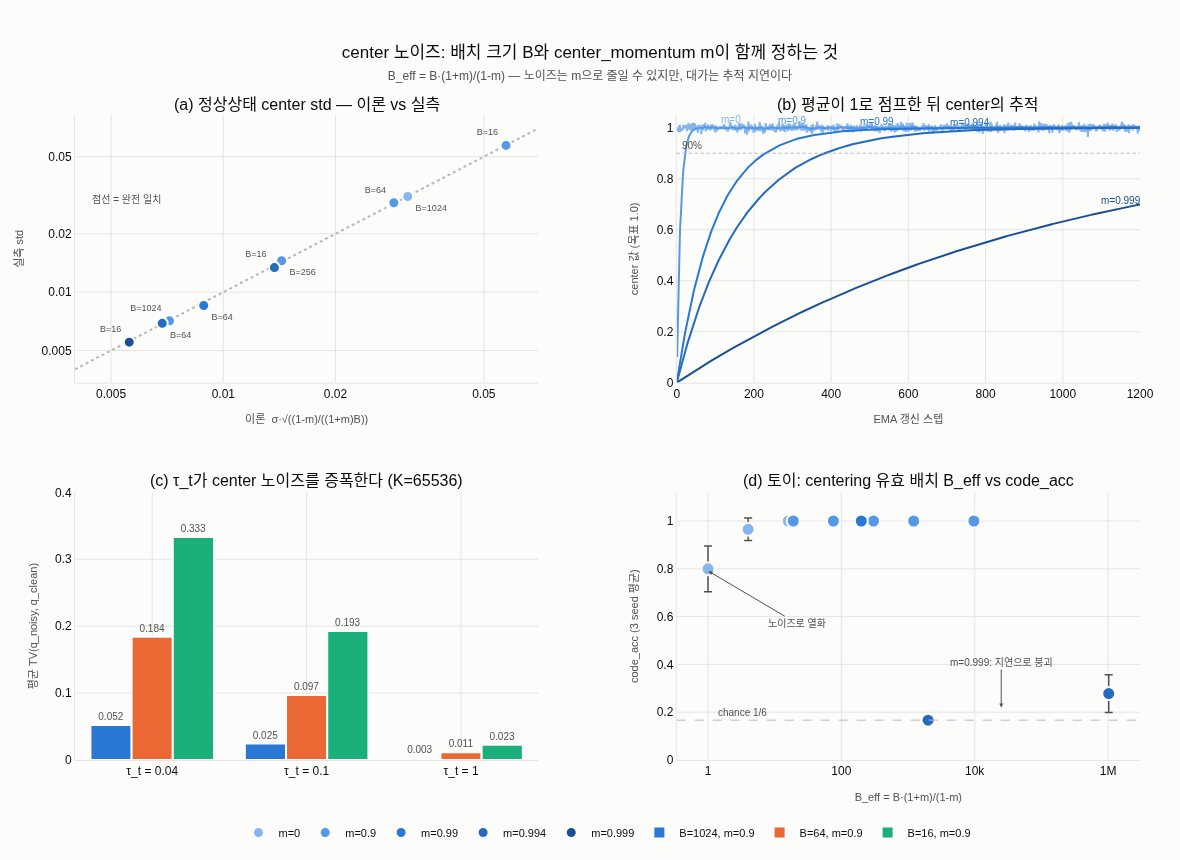

In [7]:
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=("(a) 정상상태 center std — 이론 vs 실측",
                    "(b) 평균이 1로 점프한 뒤 center의 추적",
                    "(c) τ_t가 center 노이즈를 증폭한다 (K=65536)",
                    "(d) 토이: centering 유효 배치 B_eff vs code_acc"),
    horizontal_spacing=0.13, vertical_spacing=0.17)

# --- (a) ---
ms_a = sorted({r["m"] for r in rows_a})
cmap_a = {m: SEQ[i] for i, m in enumerate(ms_a)}
fig.add_trace(go.Scatter(x=[4e-3, 7e-2], y=[4e-3, 7e-2], mode="lines",
                         line=dict(color="#b9b8b2", width=2, dash="dot"),
                         showlegend=False, hoverinfo="skip"), row=1, col=1)
# 점들이 대각선에 몰리므로 라벨 위치를 번갈아 배치한다
_pos = {}
for _i, _r in enumerate(sorted(rows_a, key=lambda r: r["th"])):
    _pos[(_r["B"], _r["m"])] = "top left" if _i % 2 == 0 else "bottom right"
for m in ms_a:
    pts = [r for r in rows_a if r["m"] == m]
    fig.add_trace(go.Scatter(
        x=[p["th"] for p in pts], y=[p["em"] for p in pts], mode="markers+text",
        text=[f"B={p['B']}" for p in pts],
        textposition=[_pos[(p["B"], p["m"])] for p in pts],
        textfont=dict(size=9, color=INK2),
        marker=dict(size=11, color=cmap_a[m], line=dict(width=2, color=SURFACE)),
        name=f"m={m:g}", legendgroup=f"m{m:g}"), row=1, col=1)
fig.add_annotation(x=math.log10(5.5e-3), y=math.log10(3.0e-2), xref="x", yref="y",
                   text="점선 = 완전 일치", showarrow=False, font=dict(size=10, color=INK2))

# --- (b) ---
_lblx = [140, 300, 520, 760, 1150]                      # 곡선 라벨을 x축으로 흩어 놓는다
for i, m in enumerate(ms_b):
    tr = tracks[m]
    fig.add_trace(go.Scatter(x=np.arange(1, len(tr) + 1), y=tr, mode="lines",
                             line=dict(color=SEQ[i], width=2), name=f"m={m:g}",
                             legendgroup=f"m{m:g}", showlegend=False), row=1, col=2)
    fig.add_annotation(x=_lblx[i], y=float(tr[_lblx[i] - 1]), xref="x2", yref="y2",
                       text=f"m={m:g}", xanchor="center", yanchor="bottom", showarrow=False,
                       font=dict(size=10, color=SEQ[i]))
fig.add_hline(y=0.9, line=dict(color="#b9b8b2", width=1, dash="dot"), row=1, col=2)
fig.add_annotation(x=40, y=0.9, xref="x2", yref="y2", text="90%", yanchor="bottom",
                   showarrow=False, font=dict(size=10, color=INK2))

# --- (c) ---
for i, (label, _) in enumerate(noise_levels):
    fig.add_trace(go.Bar(x=[f"τ_t = {t:g}" for t in taus], y=rows_c[label],
                         marker=dict(color=CAT[i], line=dict(width=2, color=SURFACE)),
                         text=[f"{v:.3f}" for v in rows_c[label]], textposition="outside",
                         textfont=dict(size=10, color=INK2), name=label), row=2, col=1)

# --- (d) ---
ms_d = sorted({r["m"] for r in res_d})
cmap_d = {m: SEQ[i] for i, m in enumerate(ms_d)}
for m in ms_d:
    pts = sorted([r for r in res_d if r["m"] == m], key=lambda r: r["beff"])
    fig.add_trace(go.Scatter(
        x=[p["beff"] for p in pts], y=[p["code_acc"] for p in pts],
        mode="markers", marker=dict(size=13, color=cmap_d[m], line=dict(width=2, color=SURFACE)),
        error_y=dict(type="data", array=[p["sd"] for p in pts], color=INK2, thickness=1.5, width=4),
        name=f"m={m:g}", legendgroup=f"m{m:g}", showlegend=False), row=2, col=2)
fig.add_hline(y=1 / 6, line=dict(color="#b9b8b2", width=1, dash="dash"), row=2, col=2)
fig.add_annotation(x=math.log10(1.3), y=1 / 6, xref="x4", yref="y4", text="chance 1/6",
                   yanchor="bottom", xanchor="left", showarrow=False, font=dict(size=10, color=INK2))
fig.add_annotation(x=math.log10(1.02), y=0.79, xref="x4", yref="y4", ax=88, ay=52,
                   text="노이즈로 열화", showarrow=True, arrowhead=2, arrowsize=0.8,
                   arrowcolor=INK2, font=dict(size=10, color=INK2))
fig.add_annotation(x=math.log10(2.5e4), y=0.22, xref="x4", yref="y4", ax=0, ay=-45,
                   text="m=0.999: 지연으로 붕괴", showarrow=True, arrowhead=2, arrowsize=0.8,
                   arrowcolor=INK2, font=dict(size=10, color=INK2))

_tv = [0.005, 0.01, 0.02, 0.05]
fig.update_xaxes(type="log", title_text="이론  σ·√((1-m)/((1+m)B))", tickvals=_tv,
                 ticktext=[str(v) for v in _tv], row=1, col=1)
fig.update_yaxes(type="log", title_text="실측 std", tickvals=_tv,
                 ticktext=[str(v) for v in _tv], row=1, col=1)
fig.update_xaxes(title_text="EMA 갱신 스텝", range=[0, 1200], row=1, col=2)
fig.update_yaxes(title_text="center 값 (목표 1.0)", range=[0, 1.05], row=1, col=2)
fig.update_yaxes(title_text="평균 TV(q_noisy, q_clean)", range=[0, 0.40], row=2, col=1)
fig.update_xaxes(type="log", title_text="B_eff = B·(1+m)/(1-m)", row=2, col=2)
fig.update_yaxes(title_text="code_acc (3 seed 평균)", range=[0, 1.12], row=2, col=2)

fig.update_layout(
    title=dict(text="center 노이즈: 배치 크기 B와 center_momentum m이 함께 정하는 것<br>"
                    "<span style='font-size:12px;color:#52514e'>"
                    "B_eff = B·(1+m)/(1-m) — 노이즈는 m으로 줄일 수 있지만, 대가는 추적 지연이다</span>",
               x=0.5, xanchor="center", font=dict(size=17, color=INK)),
    paper_bgcolor=SURFACE, plot_bgcolor=SURFACE, font=dict(color=INK, size=12),
    width=1180, height=860, barmode="group",
    legend=dict(orientation="h", y=-0.09, x=0.5, xanchor="center", font=dict(size=11)),
    margin=dict(t=115, b=100, l=75, r=40))
fig.update_xaxes(gridcolor=GRID, zeroline=False, linecolor=GRID, title_font=dict(size=11, color=INK2))
fig.update_yaxes(gridcolor=GRID, zeroline=False, linecolor=GRID, title_font=dict(size=11, color=INK2))

out_png = os.path.join(HERE, "expy.png")
fig.write_image(out_png, scale=2)
print("saved:", out_png)
_show(fig)

## 정리

| 물어볼 것 | 답 |
|---|---|
| center 노이즈 크기는? | $\sigma\sqrt{\dfrac{1-m}{(1+m)B}}$ — (a)에서 오차 4% 이내로 확인 |
| 유효 배치는? | $B_{\text{eff}}=B\cdot\dfrac{1+m}{1-m}$, $m=0.9$면 19배 |
| 배치가 작으면? | (d)에서 $B_{\text{eff}}$ 1까지 줄이면 `top_share` 0.167→0.359, $I$ 1.79→1.46 |
| $m$으로 보상되나? | 된다 — $B_c=1$에서 $m$ 0→0.99로 `code_acc` 0.80→1.00 |
| 무한정 올려도 되나? | 안 된다 — (b)의 $t_{90}\approx2300$, (d)의 $m=0.999$ → `top_share` 0.78~1.00 붕괴, 논문 Appendix D k-NN 0.1 |
| 왜 작은 노이즈가 치명적? | $\tau_t=0.04$가 25배 증폭 — (c)에서 TV 0.33, argmax 41% 뒤바뀜 |